# Thực hành 2: Làm sạch dữ liệu, EDA và chuẩn bị đặc trưng

Notebook này được viết theo kiểu giải thích từng bước, để sinh viên không chỉ **chạy ra kết quả** mà còn hiểu rõ vì sao mỗi quyết định làm sạch dữ liệu lại ảnh hưởng trực tiếp tới chất lượng phân tích và mô hình học máy.

## Bối cảnh bài toán

Hãy hình dung một văn phòng y tế của thành phố nhận dữ liệu sàng lọc từ nhiều phòng khám khác nhau. Dữ liệu gom từ nhiều nguồn như vậy thường gặp mấy vấn đề rất quen:

- thiếu dữ liệu,
- nhãn phân loại không thống nhất,
- một số biến bị ghi theo nhiều kiểu khác nhau,
- và có những cột nhìn qua tưởng hữu ích nhưng thật ra thiếu quá nhiều nên rất khó dùng.

Nếu mình đưa thẳng dữ liệu kiểu đó vào mô hình mà không kiểm tra trước, rất dễ rơi vô tình huống **"garbage in, garbage out"**: đầu vào chất lượng kém thì đầu ra cũng khó mà tốt được.

## Mục tiêu học tập

Sau khi làm xong notebook này, sinh viên nên tự trả lời được mấy câu hỏi sau:

1. Làm sao kiểm toán nhanh một bộ dữ liệu thô?
2. Khi nào nên xóa cột, khi nào nên điền giá trị thiếu, và khi nào nên giữ nguyên?
3. Vì sao phải lập kế hoạch làm sạch trước khi viết mã?
4. Làm sao tạo thêm đặc trưng mới từ dữ liệu gốc?
5. Cần chuẩn bị những gì để dữ liệu sẵn sàng cho bước mô hình hóa?

## Notebook này sẽ làm những gì?

- Tải và đọc bộ dữ liệu `Diabetes 130-US hospitals for years 1999-2008`.
- Kiểm toán dữ liệu thô: số dòng, số cột, kiểu dữ liệu, giá trị thiếu và các điểm bất thường đáng chú ý.
- Lập kế hoạch làm sạch dữ liệu dưới dạng mô tả lý do và quyết định xử lý.
- Thực thi các bước làm sạch bằng `pandas`.
- Tạo thêm vài đặc trưng cơ bản nhưng có ích cho mô hình.
- So sánh dữ liệu trước và sau làm sạch bằng bảng và biểu đồ.
- Lưu dữ liệu sạch, dữ liệu sẵn sàng mô hình hóa và từ điển dữ liệu.

> Nguồn dữ liệu gợi ý trong đề: UCI Machine Learning Repository - Diabetes 130-US hospitals for years 1999-2008.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Tắt bớt cảnh báo để lúc coi notebook cho đỡ rối mắt.
warnings.filterwarnings("ignore")

# Chỉnh cách hiển thị bảng để sinh viên nhìn được nhiều cột hơn,
# khỏi bị pandas cắt ngang quá sớm.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
plt.style.use("ggplot")

# Gom hết mấy đường dẫn quan trọng lại một chỗ cho dễ theo dõi.
# Cách này cũng tiện nếu sau này mình muốn đổi tên file hay thư mục đầu ra.
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
RAW_PATH = DATA_DIR / "diabetic_data_raw.csv"
VARIABLES_PATH = DATA_DIR / "diabetes_variables.csv"
CLEAN_PATH = DATA_DIR / "diabetic_data_clean.csv"
MODEL_READY_PATH = DATA_DIR / "diabetic_data_model_ready.csv"
DICTIONARY_PATH = OUTPUT_DIR / "data_dictionary.csv"
MISSING_COMPARE_PATH = OUTPUT_DIR / "missing_before_after.csv"

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Nếu máy chưa có dữ liệu thì notebook sẽ tự tải về từ UCI.
# Làm vậy để chạy lại từ đầu vẫn ổn, không cần ngồi chép tay file CSV vô thư mục.
if not RAW_PATH.exists() or not VARIABLES_PATH.exists():
    from ucimlrepo import fetch_ucirepo

    dataset = fetch_ucirepo(id=296)
    dataset.data.original.to_csv(RAW_PATH, index=False)
    dataset.variables.to_csv(VARIABLES_PATH, index=False)

# low_memory=False giúp pandas đọc dữ liệu ổn định hơn
# khi bộ dữ liệu có nhiều cột phân loại.
raw_df = pd.read_csv(RAW_PATH, low_memory=False)
variables_df = pd.read_csv(VARIABLES_PATH)

print(f"Kích thước dữ liệu thô: {raw_df.shape[0]:,} dòng x {raw_df.shape[1]} cột")
print(f"Số cột mô tả trong data dictionary gốc: {variables_df.shape[0]}")
print("Dữ liệu đã sẵn sàng cho bước kiểm toán ban đầu.")

Kích thước dữ liệu thô: 101,766 dòng x 50 cột
Số cột mô tả trong data dictionary gốc: 50
Dữ liệu đã sẵn sàng cho bước kiểm toán ban đầu.


## 1. Kiểm toán dữ liệu thô

Trong thực tế, trước khi làm sạch dữ liệu, mình không nên sửa liền tay. Việc đầu tiên cần làm là **kiểm toán dữ liệu thô** để hiểu coi bộ dữ liệu hiện đang ở tình trạng nào.

Ở bước này, mình muốn trả lời mấy câu hỏi nền như sau:

- Dữ liệu có bao nhiêu dòng, bao nhiêu cột?
- Mỗi cột đang có kiểu dữ liệu gì?
- Cột nào đang thiếu dữ liệu nặng?
- Có dòng nào bị trùng lặp hoàn toàn hay không?
- Có giá trị nào đáng nghi, chẳng hạn như `Unknown/Invalid` ở giới tính hay giá trị âm trong biến số không?

Một lưu ý rất quan trọng là: **không phải cứ lặp là sai**. Với dữ liệu bệnh viện, một bệnh nhân có thể xuất hiện nhiều lần vì họ nhập viện nhiều đợt khác nhau. Bởi vậy, ở đây mình chỉ xem **dòng trùng lặp hoàn toàn** là ứng viên để xóa; còn chuyện `patient_nbr` lặp lại thì phải hiểu theo đúng ngữ cảnh nghiệp vụ.

In [2]:
# Đếm số giá trị thiếu của từng cột.
# Đây là chỗ quan trọng nhất để mình quyết định cột nào nên điền,
# cột nào nên bỏ, còn cột nào thì cứ giữ nguyên.
missing_before = raw_df.isna().sum().sort_values(ascending=False)
missing_before_table = (
    pd.DataFrame({
        "missing_count_before": missing_before,
        "missing_pct_before": (missing_before / len(raw_df) * 100).round(2),
    })
    .query("missing_count_before > 0")
)

# Lập một bảng tổng quan để sinh viên nhìn một lượt là thấy luôn:
# kiểu dữ liệu, số giá trị khác nhau và mức độ thiếu dữ liệu của từng cột.
column_profile = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "non_null_count": raw_df.notna().sum(),
    "missing_count": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().sum() / len(raw_df) * 100).round(2),
    "n_unique": raw_df.nunique(dropna=True),
}).sort_values(["missing_count", "n_unique"], ascending=[False, False])

# Kiểm tra thử mấy cột số có xuất hiện giá trị âm hay không.
# Với bộ dữ liệu kiểu này, số âm thường là dấu hiệu nhập sai hoặc mã hóa chưa đúng.
numeric_cols = raw_df.select_dtypes(include="number").columns.tolist()
negative_numeric_counts = (raw_df[numeric_cols] < 0).sum()
negative_numeric_counts = negative_numeric_counts[negative_numeric_counts > 0]

# Gom vài chỉ số chính lại để mình nắm tình hình dữ liệu ban đầu cho gọn.
audit_summary = pd.DataFrame(
    [
        {"chỉ_số": "Số dòng", "giá_trị": raw_df.shape[0]},
        {"chỉ_số": "Số cột", "giá_trị": raw_df.shape[1]},
        {"chỉ_số": "Dòng trùng lặp hoàn toàn", "giá_trị": int(raw_df.duplicated().sum())},
        {"chỉ_số": "Bệnh nhân lặp theo patient_nbr", "giá_trị": int(raw_df["patient_nbr"].duplicated().sum())},
        {"chỉ_số": "Giới tính Unknown/Invalid", "giá_trị": int((raw_df["gender"] == "Unknown/Invalid").sum())},
        {"chỉ_số": "Số cột có thiếu dữ liệu", "giá_trị": int((raw_df.isna().sum() > 0).sum())},
    ]
)

print("Bảng tóm tắt kiểm toán dữ liệu:")
display(audit_summary)

print("\n5 dòng đầu tiên của dữ liệu thô:")
display(raw_df.head())

print("\n12 cột thiếu dữ liệu nhiều nhất:")
display(missing_before_table.head(12))

print("\nHồ sơ 12 cột cần ưu tiên xem xét khi làm sạch:")
display(column_profile.head(12))

if negative_numeric_counts.empty:
    print("\nKhông phát hiện giá trị âm trong các cột số.")
else:
    print("\nCó một vài cột số có giá trị âm, cần coi kỹ thêm:")
    display(negative_numeric_counts)

print("\nKiểu dữ liệu từng cột:")
display(raw_df.dtypes.to_frame("dtype"))

print(
    "\nNhận xét nhanh: bộ dữ liệu có khá nhiều cột phân loại và một số cột thiếu dữ liệu rất nhiều, "
    "nhất là weight, max_glu_serum, A1Cresult và medical_specialty."
)

Bảng tóm tắt kiểm toán dữ liệu:


,chỉ_số,giá_trị
0,Số dòng,101766
1,Số cột,50
2,Dòng trùng lặp hoàn toàn,0
3,Bệnh nhân lặp theo patient_nbr,30248
4,Giới tính Unknown/Invalid,3
5,Số cột có thiếu dữ liệu,9



5 dòng đầu tiên của dữ liệu thô:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



12 cột thiếu dữ liệu nhiều nhất:


...


Hồ sơ 12 cột cần ưu tiên xem xét khi làm sạch:


,dtype,non_null_count,missing_count,missing_pct,n_unique
weight,str,3197,98569,96.86,9
max_glu_serum,str,5346,96420,94.75,3
A1Cresult,str,17018,84748,83.28,3
medical_specialty,str,51817,49949,49.08,72
payer_code,str,61510,40256,39.56,17
race,str,99493,2273,2.23,5
diag_3,str,100343,1423,1.40,789
diag_2,str,101408,358,0.35,748
diag_1,str,101745,21,0.02,716
encounter_id,int64,101766,0,0.00,101766



Không phát hiện giá trị âm trong các cột số.

Kiểu dữ liệu từng cột:


,dtype
encounter_id,int64
patient_nbr,int64
race,str
gender,str
age,str
weight,str
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



Nhận xét nhanh: bộ dữ liệu có khá nhiều cột phân loại và một số cột thiếu dữ liệu rất nhiều, nhất là weight, max_glu_serum, A1Cresult và medical_specialty.


## 2. Lập kế hoạch làm sạch

Trước khi viết mã làm sạch, mình nên dừng lại một chút để trả lời câu hỏi quan trọng này: **mỗi vấn đề dữ liệu sẽ được xử lý theo nguyên tắc nào?**

$$
\begin{aligned}
\textbf{(1) } \texttt{weight} &: \text{Loại bỏ cột vì tỷ lệ thiếu dữ liệu xấp xỉ } 96.9\% \text{, quá cao để bổ sung một cách đáng tin cậy.} \\
\textbf{(2) } \texttt{race, payer\_code, medical\_specialty} &: \text{Điền nhãn } \texttt{Unknown} \text{ để giữ lại bản ghi và thể hiện rõ là thông tin chưa có.} \\
\textbf{(3) } \texttt{max\_glu\_serum, A1Cresult} &: \text{Điền } \texttt{NotMeasured} \text{ thay vì xem như thiếu ngẫu nhiên, vì việc không đo xét nghiệm cũng mang ý nghĩa nghiệp vụ.} \\
\textbf{(4) } \texttt{diag\_1, diag\_2, diag\_3} &: \text{Điền } \texttt{Missing} \text{ để tách bạch trường hợp thiếu dữ liệu với mã ICD hợp lệ.} \\
\textbf{(5) } \texttt{gender} &: \text{Chuẩn hóa } \texttt{Unknown/Invalid} \text{ thành } \texttt{Unknown} \text{ để giảm tình trạng nhãn không thống nhất.} \\
\textbf{(6) Dòng trùng lặp hoàn toàn} &: \text{Nếu có thì xóa. Tuy nhiên, không xóa các bệnh nhân lặp theo } \texttt{patient\_nbr} \text{ vì đó có thể là nhiều lần nhập viện hợp lệ.} \\
\textbf{(7) Đặc trưng mới} &: \text{Tạo } \texttt{total\_prev\_visits, long\_stay\_flag, high\_glucose\_flag, poor\_a1c\_flag} \\
& \text{ để gom thông tin nghiệp vụ thành các biến đầu vào dễ học hơn cho mô hình.} \\
\textbf{(8) Biến mục tiêu hỗ trợ} &: \text{Tạo } \texttt{readmitted\_binary} \text{ để biểu diễn rõ trường hợp tái nhập viện trong vòng 30 ngày.} \\
\textbf{(9) Dữ liệu sẵn sàng mô hình hóa} &: \text{Mã hóa one-hot cho các biến phân loại và chuẩn hóa z-score cho các biến số} \\
& \text{ để chuẩn bị một phiên bản dữ liệu có thể đưa vào mô hình học máy.}
\end{aligned}
$$

Nhìn lại phần này, mình có thể xem đây như một “bản cam kết xử lý dữ liệu”. Tức là ở phần triển khai phía sau, mọi thao tác đều phải bám đúng những gì đã lên kế hoạch ở đây.

## 3. Triển khai làm sạch và tạo đặc trưng

Ở phần này, mình chuyển từ **ra quyết định** sang **thực thi bằng mã**. Một nguyên tắc rất nên giữ là làm sạch theo từng nhóm vấn đề, chứ đừng gom hết vô một khối lệnh dài ngoằng khó đọc.

Thứ tự triển khai trong notebook này như sau:

1. Chuẩn hóa các nhãn phân loại chưa thống nhất.
2. Điền giá trị thiếu đúng theo kế hoạch đã lập.
3. Loại bỏ cột không còn phù hợp để sử dụng.
4. Kiểm tra và xóa dòng trùng lặp hoàn toàn nếu có.
5. Tạo thêm đặc trưng mới để làm giàu thông tin cho mô hình.
6. Tạo biến mục tiêu hỗ trợ cho bài toán phân loại.
7. Chuẩn bị một phiên bản dữ liệu sẵn sàng cho mô hình hóa bằng one-hot encoding và chuẩn hóa biến số.

Nói cách khác, phần này phải **ăn khớp hoàn toàn** với phần “Lập kế hoạch làm sạch” ở trên. Nếu trong mã có bước nào không xuất hiện trong kế hoạch, hoặc ngược lại, thì quy trình chưa thật sự đồng bộ.

### Vì sao cần tạo đặc trưng?

Nhiều khi dữ liệu gốc đã có đủ thông tin, nhưng chưa ở dạng thuận tiện cho mô hình học máy. Ví dụ:

- Ba biến `number_outpatient`, `number_emergency`, `number_inpatient` đang tách rời nhau, nhưng tổng số lần sử dụng dịch vụ y tế trong năm trước có thể là một tín hiệu mạnh hơn.
- `time_in_hospital` là biến số liên tục, nhưng cờ `long_stay_flag` giúp mô hình nhận ra nhanh nhóm bệnh nhân nằm viện dài ngày.
- `max_glu_serum` và `A1Cresult` có thể rút gọn thành cờ nhị phân để nhấn mạnh các trường hợp rủi ro cao.

### Vì sao cần one-hot encoding và scaling?

- **One-hot encoding** biến dữ liệu phân loại thành dạng số để mô hình có thể xử lý.
- **Scaling** đưa các biến số về cùng thang đo tương đối, giúp những mô hình nhạy với độ lớn của đặc trưng hoạt động ổn định hơn.

Công thức chuẩn hóa z-score dùng ở đây là:

$$
z = \frac{x - \mu}{\sigma}
$$

trong đó $\mu$ là giá trị trung bình còn $\sigma$ là độ lệch chuẩn của biến.

In [3]:
# Tạo một bản sao của dữ liệu thô để mình xử lý trên bản copy,
# chứ không đụng trực tiếp vô dữ liệu gốc.
clean_df = raw_df.copy()

# ---------------------------------------------------------------------
# 1. CHUẨN HÓA CÁC NHÃN CHƯA NHẤT QUÁN
# ---------------------------------------------------------------------
# Cột gender có 3 trường hợp là 'Unknown/Invalid'.
# Mình đổi hết thành 'Unknown' cho gọn và đồng nhất hơn.
clean_df["gender"] = clean_df["gender"].replace({"Unknown/Invalid": "Unknown"})

# ---------------------------------------------------------------------
# 2. ĐIỀN GIÁ TRỊ THIẾU THEO TỪNG NHÓM CỘT
# ---------------------------------------------------------------------
# Với mấy cột phân loại tổng quát, mình điền 'Unknown'.
# Ý ở đây là giữ lại bản ghi, đồng thời nói rõ là thông tin này chưa có.
for col in ["race", "payer_code", "medical_specialty"]:
    clean_df[col] = clean_df[col].fillna("Unknown")

# Riêng max_glu_serum và A1Cresult thì ô trống không hẳn là mất dữ liệu ngẫu nhiên,
# mà nhiều khi có nghĩa là xét nghiệm đó không được thực hiện.
# Nên ở đây mình dùng nhãn 'NotMeasured' sẽ sát nghĩa hơn.
for col in ["max_glu_serum", "A1Cresult"]:
    clean_df[col] = clean_df[col].fillna("NotMeasured")

# Mấy cột chẩn đoán thì điền 'Missing' để tách rõ
# giữa trường hợp thiếu dữ liệu và trường hợp có mã ICD hợp lệ.
for col in ["diag_1", "diag_2", "diag_3"]:
    clean_df[col] = clean_df[col].fillna("Missing").astype(str)

# ---------------------------------------------------------------------
# 3. LOẠI BỎ NHỮNG PHẦN KHÔNG CÒN PHÙ HỢP
# ---------------------------------------------------------------------
# Cột weight thiếu quá nhiều nên giữ lại cũng khó xài,
# vậy mình bỏ nguyên cột này.
clean_df = clean_df.drop(columns=["weight"])

# Nếu có dòng trùng lặp hoàn toàn thì mình xóa.
# Bộ dữ liệu này thực tế không có dòng nào như vậy, nhưng cứ để lệnh ở đây
# để quy trình nhìn trọn vẹn và xài lại cho dữ liệu khác cũng được.
rows_before_dedup = len(clean_df)
clean_df = clean_df.drop_duplicates()
rows_removed = rows_before_dedup - len(clean_df)

# ---------------------------------------------------------------------
# 4. TẠO THÊM ĐẶC TRƯNG MỚI
# ---------------------------------------------------------------------
# Tổng số lần bệnh nhân đã tiếp xúc với hệ thống y tế trong năm trước đó.
clean_df["total_prev_visits"] = (
    clean_df["number_outpatient"]
    + clean_df["number_emergency"]
    + clean_df["number_inpatient"]
)

# Tạo cờ cho trường hợp nằm viện dài ngày.
# Ở đây mình chọn ngưỡng 7 ngày để biến nó thành biến nhị phân.
clean_df["long_stay_flag"] = (clean_df["time_in_hospital"] >= 7).astype(int)

# Tạo cờ cho những trường hợp có dấu hiệu đường huyết cao.
clean_df["high_glucose_flag"] = clean_df["max_glu_serum"].isin([">200", ">300"]).astype(int)

# Tạo cờ cho nhóm A1C đáng lưu ý.
# Cả >7 và >8 đều được xem là mức cần quan tâm trong bài này.
clean_df["poor_a1c_flag"] = clean_df["A1Cresult"].isin([">7", ">8"]).astype(int)

# Tạo biến mục tiêu hỗ trợ cho bài toán phân loại:
# bằng 1 nếu bệnh nhân tái nhập viện trong vòng 30 ngày.
clean_df["readmitted_binary"] = (clean_df["readmitted"] == "<30").astype(int)

# ---------------------------------------------------------------------
# 5. ĐỐI CHIẾU CHẤT LƯỢNG DỮ LIỆU TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
missing_before = raw_df.isna().sum()
missing_after = clean_df.isna().sum()

missing_compare = pd.DataFrame({
    "thiếu_trước": missing_before,
    "thiếu_sau": missing_after,
})
missing_compare["thiếu_sau"] = missing_compare["thiếu_sau"].fillna(0).astype(int)
missing_compare["trạng_thái"] = "Giữ lại"
missing_compare.loc[~missing_compare.index.isin(clean_df.columns), "trạng_thái"] = "Đã loại bỏ"
missing_compare = missing_compare.sort_values("thiếu_trước", ascending=False)
missing_compare.to_csv(MISSING_COMPARE_PATH, encoding="utf-8-sig", index_label="column")

missing_after_table = (
    pd.DataFrame({
        "missing_count_after": clean_df.isna().sum(),
        "missing_pct_after": (clean_df.isna().sum() / len(clean_df) * 100).round(2),
    })
    .query("missing_count_after > 0")
)

# Bảng tóm tắt này giúp mình thấy nhanh dữ liệu đã thay đổi ra sao sau khi làm sạch.
quality_summary = pd.DataFrame(
    [
        {"chỉ_số": "Số dòng", "trước": raw_df.shape[0], "sau": clean_df.shape[0]},
        {"chỉ_số": "Số cột", "trước": raw_df.shape[1], "sau": clean_df.shape[1]},
        {"chỉ_số": "Tổng số giá trị thiếu", "trước": int(raw_df.isna().sum().sum()), "sau": int(clean_df.isna().sum().sum())},
        {"chỉ_số": "Dòng trùng lặp hoàn toàn", "trước": int(raw_df.duplicated().sum()), "sau": int(clean_df.duplicated().sum())},
    ]
)

# ---------------------------------------------------------------------
# 6. CHUẨN BỊ DỮ LIỆU SẴN SÀNG CHO MÔ HÌNH
# ---------------------------------------------------------------------
# encounter_id với patient_nbr là mã định danh,
# còn readmitted là nhãn gốc dạng chữ.
# Mình tách mấy cột này ra khỏi tập đặc trưng đầu vào.
feature_cols = [c for c in clean_df.columns if c not in ["encounter_id", "patient_nbr", "readmitted"]]
categorical_cols = clean_df[feature_cols].select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols and c != "readmitted_binary"]

# One-hot encoding sẽ đổi các cột phân loại thành nhiều cột 0/1,
# để mô hình học máy xử lý được.
model_ready_df = pd.get_dummies(
    clean_df[feature_cols],
    columns=categorical_cols,
    drop_first=False,
    dtype=int,
)

# Chuẩn hóa các cột số bằng z-score.
# Nếu cột nào có độ lệch chuẩn bằng 0, tức là mọi giá trị giống nhau,
# thì mình cho cột đó về 0 để khỏi bị chia cho 0.
for col in numeric_cols:
    std = model_ready_df[col].std()
    if pd.notna(std) and std != 0:
        model_ready_df[col] = (model_ready_df[col] - model_ready_df[col].mean()) / std
    else:
        model_ready_df[col] = 0

# Đưa biến mục tiêu xuống cuối bảng để lúc coi dữ liệu cho dễ nhìn.
model_ready_df["readmitted_binary"] = clean_df["readmitted_binary"]

# ---------------------------------------------------------------------
# 7. LƯU CÁC FILE ĐÃ XỬ LÝ
# ---------------------------------------------------------------------
clean_df.to_csv(CLEAN_PATH, index=False)
model_ready_df.to_csv(MODEL_READY_PATH, index=False)

print(f"Số dòng bị xóa do trùng lặp hoàn toàn: {rows_removed}")
print(f"Dữ liệu sau làm sạch: {clean_df.shape[0]:,} dòng x {clean_df.shape[1]} cột")
print(f"Dữ liệu sẵn sàng mô hình hóa: {model_ready_df.shape[0]:,} dòng x {model_ready_df.shape[1]} cột")
print(f"Số cột còn thiếu dữ liệu sau làm sạch: {(clean_df.isna().sum() > 0).sum()}")

print("\nBảng tóm tắt chất lượng dữ liệu trước và sau làm sạch:")
display(quality_summary)

print("\nBảng so sánh giá trị thiếu trước và sau làm sạch (12 cột đầu):")
display(missing_compare.head(12))

if missing_after_table.empty:
    print("\nSau khi làm sạch, dữ liệu không còn giá trị thiếu nữa.")
else:
    print("\nNếu vẫn còn cột thiếu dữ liệu, mình cần xem kỹ bảng sau:")
    display(missing_after_table.head(12))

print("\nMột vài cột tiêu biểu sau khi đã tạo đặc trưng mới:")
display(clean_df[[
    "race", "gender", "time_in_hospital", "max_glu_serum", "A1Cresult",
    "total_prev_visits", "long_stay_flag", "high_glucose_flag", "poor_a1c_flag", "readmitted"
]].head())

Số dòng bị xóa do trùng lặp hoàn toàn: 0
Dữ liệu sau làm sạch: 101,766 dòng x 54 cột
Dữ liệu sẵn sàng mô hình hóa: 101,766 dòng x 2465 cột
Số cột còn thiếu dữ liệu sau làm sạch: 0

Bảng tóm tắt chất lượng dữ liệu trước và sau làm sạch:


,chỉ_số,trước,sau
0,Số dòng,101766,101766
1,Số cột,50,54
2,Tổng số giá trị thiếu,374017,0
3,Dòng trùng lặp hoàn toàn,0,0



Bảng so sánh giá trị thiếu trước và sau làm sạch (12 cột đầu):


,thiếu_trước,thiếu_sau,trạng_thái
weight,98569.0,0,Đã loại bỏ
max_glu_serum,96420.0,0,Giữ lại
A1Cresult,84748.0,0,Giữ lại
medical_specialty,49949.0,0,Giữ lại
payer_code,40256.0,0,Giữ lại
race,2273.0,0,Giữ lại
diag_3,1423.0,0,Giữ lại
diag_2,358.0,0,Giữ lại
diag_1,21.0,0,Giữ lại
acarbose,0.0,0,Giữ lại



Sau khi làm sạch, dữ liệu không còn giá trị thiếu nữa.

Một vài cột tiêu biểu sau khi đã tạo đặc trưng mới:


,race,gender,time_in_hospital,max_glu_serum,A1Cresult,total_prev_visits,long_stay_flag,high_glucose_flag,poor_a1c_flag,readmitted
0,Caucasian,Female,1,NotMeasured,NotMeasured,0,0,0,0,NO
1,Caucasian,Female,3,NotMeasured,NotMeasured,0,0,0,0,>30
2,AfricanAmerican,Female,2,NotMeasured,NotMeasured,3,0,0,0,NO
3,Caucasian,Male,2,NotMeasured,NotMeasured,0,0,0,0,NO
4,Caucasian,Male,1,NotMeasured,NotMeasured,0,0,0,0,NO


## 4. Biểu đồ so sánh dữ liệu thô và dữ liệu đã làm sạch

Đề bài chỉ yêu cầu ít nhất ba biểu đồ, nhưng nếu mình dừng ở mức “đủ ba hình” thì phần so sánh vẫn còn hơi mỏng. Vì vậy, ở đây mình mở rộng phần trực quan hóa để nhìn sự thay đổi của dữ liệu theo nhiều góc hơn.

Cụ thể, phần này sẽ trả lời các câu hỏi sau:

1. Sau làm sạch, tổng quan chất lượng dữ liệu thay đổi ra sao?
2. Các cột thiếu dữ liệu nhiều nhứt đã được xử lý như thế nào?
3. Với các biến xét nghiệm như `A1Cresult` và `max_glu_serum`, việc đổi nhãn thiếu thành `NotMeasured` có giúp dữ liệu dễ hiểu hơn không?
4. Với các biến phân loại như `medical_specialty` và `gender`, việc chuẩn hóa nhãn có làm cách biểu diễn dữ liệu thống nhất hơn không?

Khi đọc các biểu đồ bên dưới, sinh viên nên chú ý hai chuyện:

- **Phân bố có bị méo đi không?** Nếu mình làm sạch mà khiến dữ liệu đổi bản chất quá mạnh, có thể là mình đang xử lý chưa hợp lý.
- **Dữ liệu sau làm sạch có dễ diễn giải hơn không?** Làm sạch tốt không chỉ để mô hình chạy được, mà còn để con người nhìn vô là hiểu hơn.

Nói ngắn gọn, phần này không chỉ để “trang trí cho có biểu đồ”, mà để kiểm tra xem các quyết định ở phần làm sạch có thật sự giúp dữ liệu sáng sủa hơn hay không.

Bảng tóm tắt chất lượng dữ liệu trước và sau làm sạch:


,chỉ_số,trước,sau
0,Số dòng,101766,101766
1,Số cột,50,54
2,Tổng số giá trị thiếu,374017,0
3,Dòng trùng lặp hoàn toàn,0,0



10 cột có thay đổi nhiều nhất về tình trạng thiếu dữ liệu:


,thiếu_trước,thiếu_sau,trạng_thái
weight,98569.0,0,Đã loại bỏ
max_glu_serum,96420.0,0,Giữ lại
A1Cresult,84748.0,0,Giữ lại
medical_specialty,49949.0,0,Giữ lại
payer_code,40256.0,0,Giữ lại
race,2273.0,0,Giữ lại
diag_3,1423.0,0,Giữ lại
diag_2,358.0,0,Giữ lại
diag_1,21.0,0,Giữ lại
acarbose,0.0,0,Giữ lại


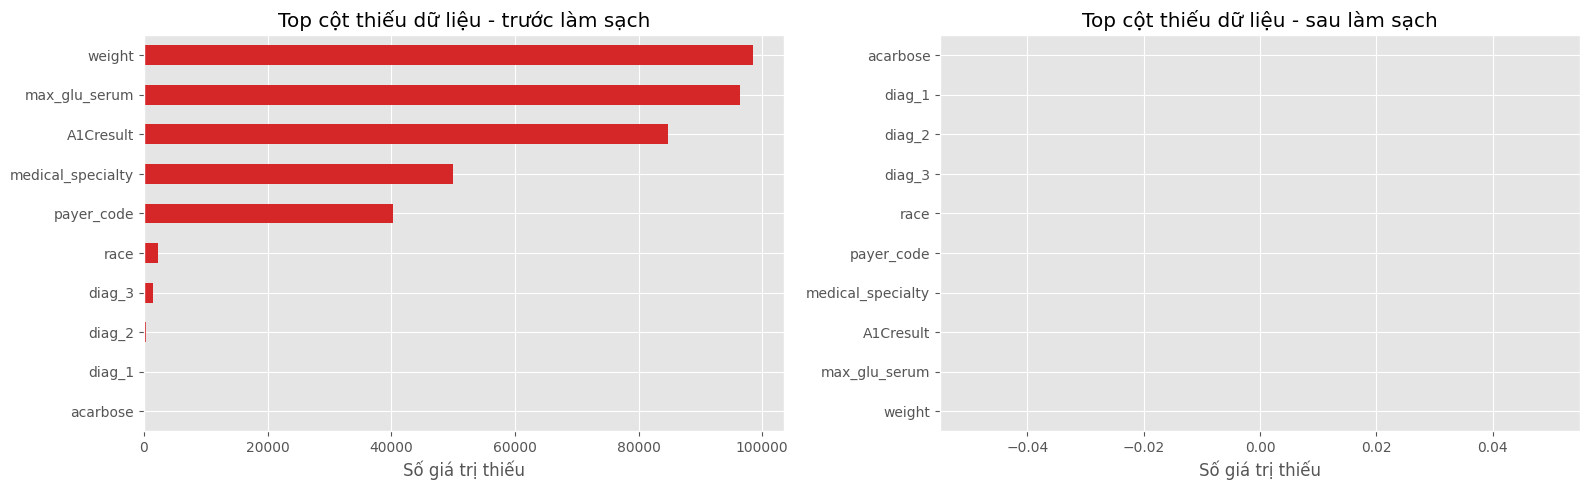

Nhận xét: nhìn vào hai biểu đồ này, mình thấy ngay số lượng giá trị thiếu đã giảm rất mạnh. Riêng cột weight biến mất khỏi dữ liệu sạch vì nó đã được loại bỏ theo đúng kế hoạch.


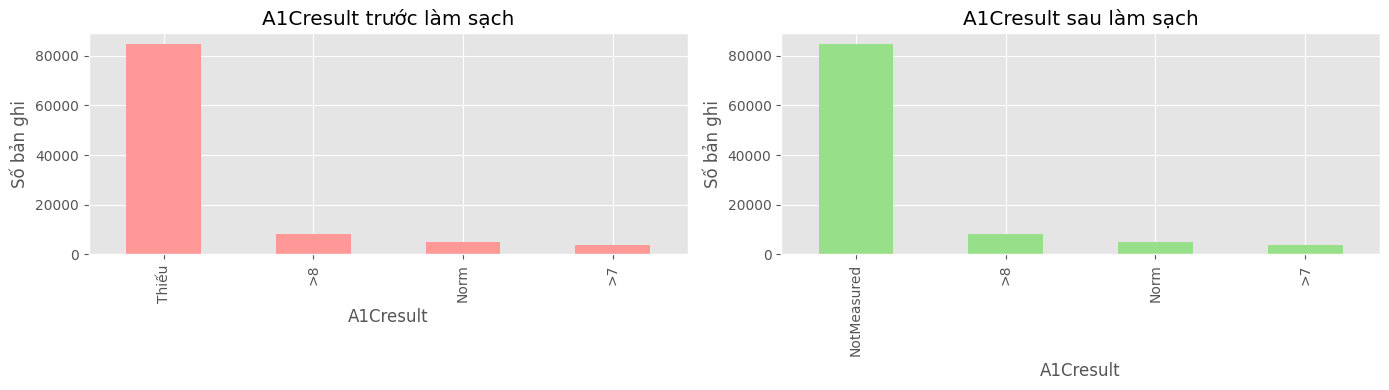

Nhận xét: việc đổi từ 'Thiếu' sang 'NotMeasured' không làm thay đổi số bản ghi, nhưng làm cho cách diễn giải dữ liệu rõ nghĩa hơn về mặt nghiệp vụ.


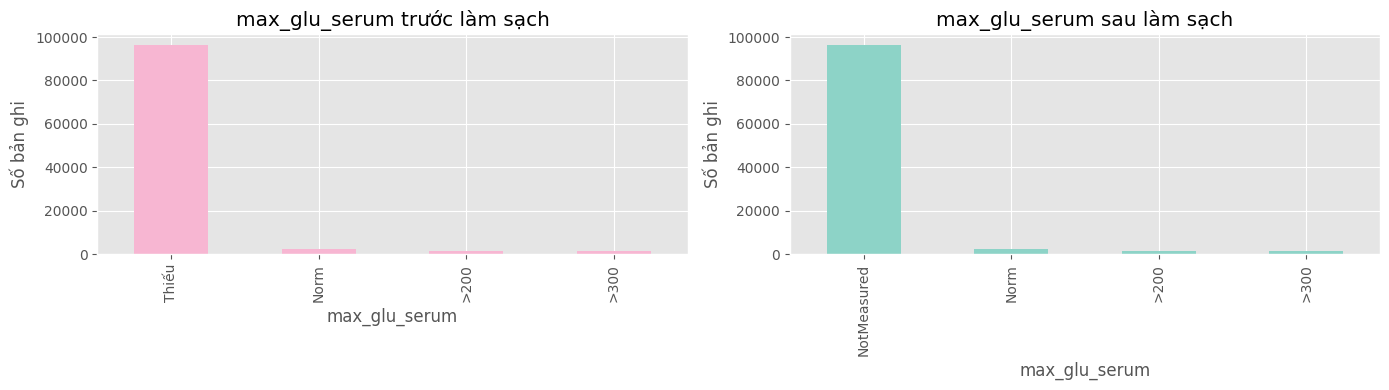

Nhận xét: biến max_glu_serum cũng cho thấy cùng một logic với A1Cresult. Sau làm sạch, mình không chỉ lấp chỗ trống mà còn diễn giải đúng bản chất là xét nghiệm chưa được đo.


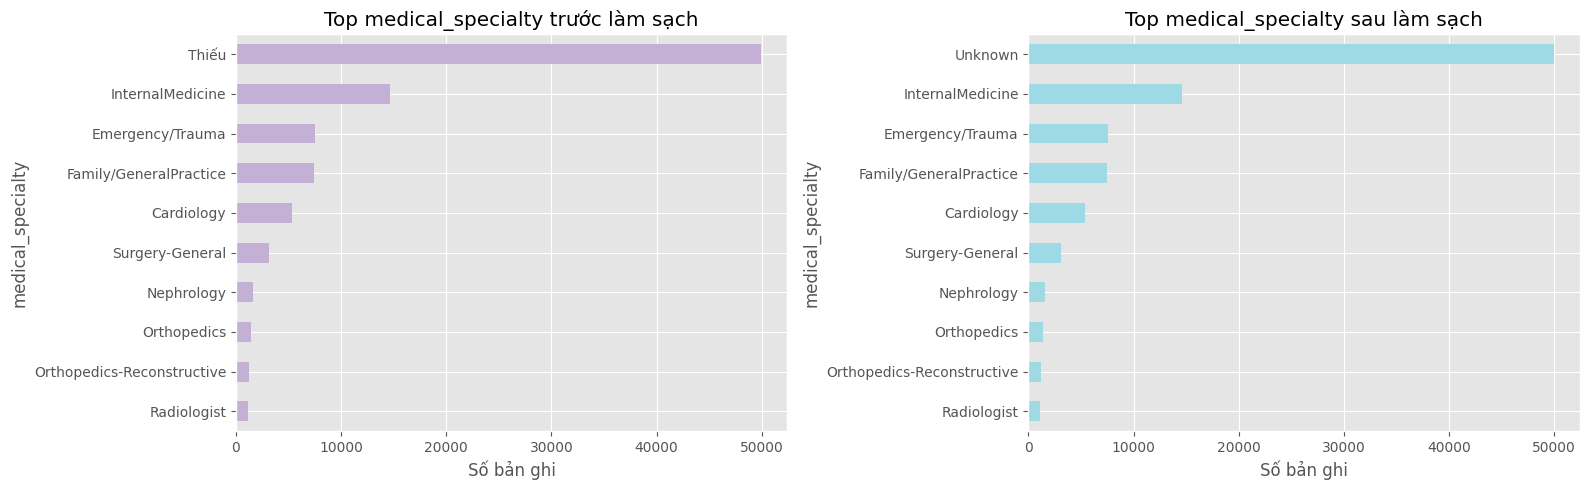

Nhận xét: sau khi làm sạch, nhãn 'Unknown' trở thành một nhóm hợp lệ và thống nhất. Nhờ vậy mình phân biệt rõ hơn giữa thông tin chuyên khoa có ghi nhận và thông tin chưa có.


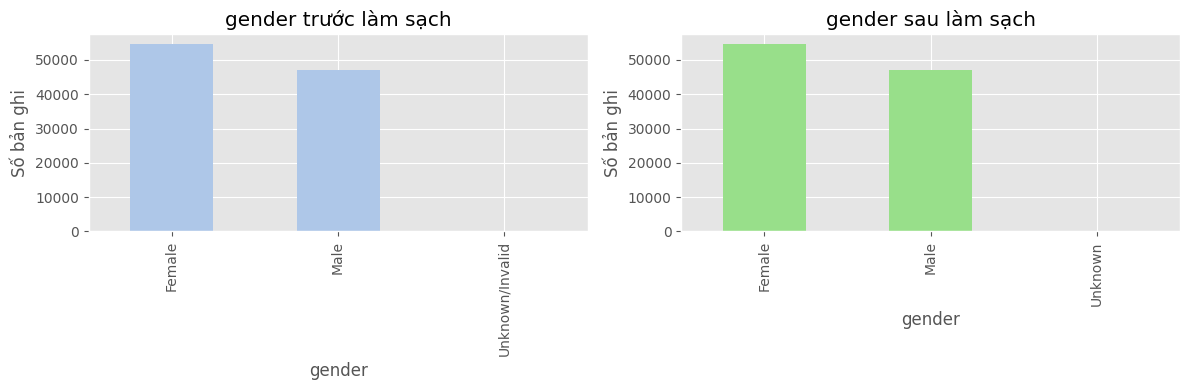

Nhận xét: khác biệt ở đây không lớn về mặt số lượng, nhưng rất quan trọng về mặt chuẩn hóa nhãn. 'Unknown/Invalid' đã được gom về 'Unknown', giúp dữ liệu nhất quán hơn khi đem đi mã hóa.

Kết luận phần so sánh: sau làm sạch, dữ liệu không chỉ giảm thiếu dữ liệu mà còn rõ nghĩa hơn, nhất quán hơn, và sẵn sàng hơn cho bước mô hình hóa phía sau.


In [4]:
# Lấy 10 cột có số lượng giá trị thiếu cao nhất để vẽ biểu đồ.
# Nếu vẽ hết toàn bộ cột thì hình sẽ bị dày, coi khá rối.
top_missing_cols = missing_compare.head(10).index.tolist()
compare_visual = missing_compare.copy()

# ---------------------------------------------------------------------
# BẢNG TÓM TẮT TRƯỚC KHI XEM BIỂU ĐỒ
# ---------------------------------------------------------------------
print("Bảng tóm tắt chất lượng dữ liệu trước và sau làm sạch:")
display(quality_summary)

print("\n10 cột có thay đổi nhiều nhất về tình trạng thiếu dữ liệu:")
display(compare_visual.head(10))

# ---------------------------------------------------------------------
# BIỂU ĐỒ 1: SO SÁNH SỐ GIÁ TRỊ THIẾU TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
compare_visual.loc[top_missing_cols, "thiếu_trước"].sort_values().plot(
    kind="barh", ax=axes[0], color="#d62728", title="Top cột thiếu dữ liệu - trước làm sạch"
)
compare_visual.loc[top_missing_cols, "thiếu_sau"].sort_values().plot(
    kind="barh", ax=axes[1], color="#2ca02c", title="Top cột thiếu dữ liệu - sau làm sạch"
)
axes[0].set_xlabel("Số giá trị thiếu")
axes[1].set_xlabel("Số giá trị thiếu")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: nhìn vào hai biểu đồ này, mình thấy ngay số lượng giá trị thiếu đã giảm rất mạnh. "
    "Riêng cột weight biến mất khỏi dữ liệu sạch vì nó đã được loại bỏ theo đúng kế hoạch."
)

# ---------------------------------------------------------------------
# BIỂU ĐỒ 2: PHÂN BỐ A1Cresult TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_df["A1Cresult"].fillna("Thiếu").value_counts().plot(
    kind="bar", ax=axes[0], color="#ff9896", title="A1Cresult trước làm sạch"
)
clean_df["A1Cresult"].value_counts().plot(
    kind="bar", ax=axes[1], color="#98df8a", title="A1Cresult sau làm sạch"
)
axes[0].set_ylabel("Số bản ghi")
axes[1].set_ylabel("Số bản ghi")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: việc đổi từ 'Thiếu' sang 'NotMeasured' không làm thay đổi số bản ghi, "
    "nhưng làm cho cách diễn giải dữ liệu rõ nghĩa hơn về mặt nghiệp vụ."
)

# ---------------------------------------------------------------------
# BIỂU ĐỒ 3: PHÂN BỐ max_glu_serum TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_df["max_glu_serum"].fillna("Thiếu").value_counts().plot(
    kind="bar", ax=axes[0], color="#f7b6d2", title="max_glu_serum trước làm sạch"
)
clean_df["max_glu_serum"].value_counts().plot(
    kind="bar", ax=axes[1], color="#8dd3c7", title="max_glu_serum sau làm sạch"
)
axes[0].set_ylabel("Số bản ghi")
axes[1].set_ylabel("Số bản ghi")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: biến max_glu_serum cũng cho thấy cùng một logic với A1Cresult. "
    "Sau làm sạch, mình không chỉ lấp chỗ trống mà còn diễn giải đúng bản chất là xét nghiệm chưa được đo."
)

# ---------------------------------------------------------------------
# BIỂU ĐỒ 4: PHÂN BỐ medical_specialty TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
raw_specialty = raw_df["medical_specialty"].fillna("Thiếu").value_counts().head(10)
clean_specialty = clean_df["medical_specialty"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_specialty.sort_values().plot(
    kind="barh", ax=axes[0], color="#c5b0d5", title="Top medical_specialty trước làm sạch"
)
clean_specialty.sort_values().plot(
    kind="barh", ax=axes[1], color="#9edae5", title="Top medical_specialty sau làm sạch"
)
axes[0].set_xlabel("Số bản ghi")
axes[1].set_xlabel("Số bản ghi")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: sau khi làm sạch, nhãn 'Unknown' trở thành một nhóm hợp lệ và thống nhất. "
    "Nhờ vậy mình phân biệt rõ hơn giữa thông tin chuyên khoa có ghi nhận và thông tin chưa có."
)

# ---------------------------------------------------------------------
# BIỂU ĐỒ 5: PHÂN BỐ gender TRƯỚC VÀ SAU LÀM SẠCH
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_df["gender"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[0], color="#aec7e8", title="gender trước làm sạch"
)
clean_df["gender"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], color="#98df8a", title="gender sau làm sạch"
)
axes[0].set_ylabel("Số bản ghi")
axes[1].set_ylabel("Số bản ghi")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: khác biệt ở đây không lớn về mặt số lượng, nhưng rất quan trọng về mặt chuẩn hóa nhãn. "
    "'Unknown/Invalid' đã được gom về 'Unknown', giúp dữ liệu nhất quán hơn khi đem đi mã hóa."
)

print(
    "\nKết luận phần so sánh: sau làm sạch, dữ liệu không chỉ giảm thiếu dữ liệu mà còn rõ nghĩa hơn, "
    "nhất quán hơn, và sẵn sàng hơn cho bước mô hình hóa phía sau."
)

## 5. Từ điển dữ liệu ngắn và lưu kết quả

Một bộ dữ liệu sạch mà không có mô tả cột thì vẫn khó xài cho người khác. Bởi vậy, ngoài chuyện lưu file CSV, mình cũng tạo thêm một **từ điển dữ liệu ngắn**.

Mục đích của từ điển dữ liệu là:

- cho biết mỗi cột có ý nghĩa gì,
- phân biệt cột gốc với cột được tạo thêm,
- giúp người chấm hoặc người dùng về sau hiểu nhanh bộ dữ liệu mà không cần đọc lại toàn bộ notebook.

Ở cell dưới, mình kết hợp mô tả cột gốc từ UCI với các đặc trưng mới được tạo ra trong quá trình làm sạch.

In [5]:
# Lấy phần mô tả cột gốc từ metadata của UCI.
# Mình đổi lại tên cột cho bảng từ điển dữ liệu nhìn gọn và dễ hiểu hơn.
base_dictionary = variables_df[["name", "role", "type", "description"]].copy()
base_dictionary.columns = ["column", "role", "type", "description"]
base_dictionary["included_in_clean_dataset"] = base_dictionary["column"].isin(clean_df.columns)

# Bổ sung thêm mấy cột mới mà notebook vừa tạo ra.
# Sinh viên hay quên khúc này, nên tới lúc mở file CSV ra sẽ không nhớ cột mới có ý nghĩa gì.
engineered_dictionary = pd.DataFrame(
    [
        {
            "column": "total_prev_visits",
            "role": "Engineered feature",
            "type": "Integer",
            "description": "Tổng số lần khám ngoại trú, cấp cứu và nội trú trong năm trước đó.",
            "included_in_clean_dataset": True,
        },
        {
            "column": "long_stay_flag",
            "role": "Engineered feature",
            "type": "Binary",
            "description": "Nhận 1 nếu thời gian nằm viện từ 7 ngày trở lên, ngược lại là 0.",
            "included_in_clean_dataset": True,
        },
        {
            "column": "high_glucose_flag",
            "role": "Engineered feature",
            "type": "Binary",
            "description": "Nhận 1 nếu max_glu_serum là >200 hoặc >300.",
            "included_in_clean_dataset": True,
        },
        {
            "column": "poor_a1c_flag",
            "role": "Engineered feature",
            "type": "Binary",
            "description": "Nhận 1 nếu A1Cresult là >7 hoặc >8.",
            "included_in_clean_dataset": True,
        },
        {
            "column": "readmitted_binary",
            "role": "Target helper",
            "type": "Binary",
            "description": "Nhận 1 nếu bệnh nhân tái nhập viện trong vòng 30 ngày ('<30').",
            "included_in_clean_dataset": True,
        },
    ]
)

# Gộp mô tả cột gốc với cột mới thành một bảng duy nhất,
# để lúc nộp bài hoặc coi lại thì tiện hơn nhiều.
data_dictionary = pd.concat([base_dictionary, engineered_dictionary], ignore_index=True)
data_dictionary.to_csv(DICTIONARY_PATH, index=False)

print("24 dòng đầu của data dictionary:")
display(data_dictionary.head(24))

print("\nCác file đầu ra quan trọng đã được lưu:")
print(f"- Dữ liệu sạch: {CLEAN_PATH}")
print(f"- Dữ liệu sẵn sàng mô hình hóa: {MODEL_READY_PATH}")
print(f"- So sánh missing trước/sau: {MISSING_COMPARE_PATH}")
print(f"- Data dictionary: {DICTIONARY_PATH}")

24 dòng đầu của data dictionary:


,column,role,type,description,included_in_clean_dataset
0,encounter_id,ID,,Unique identifier of an encounter,True
1,patient_nbr,ID,,Unique identifier of a patient,True
2,race,Feature,Categorical,"Values: Caucasian, Asian, African American, Hi...",True
3,gender,Feature,Categorical,"Values: male, female, and unknown/invalid",True
4,age,Feature,Categorical,"Grouped in 10-year intervals: [0, 10), [10, 20...",True
5,weight,Feature,Categorical,Weight in pounds.,False
6,admission_type_id,Feature,Categorical,Integer identifier corresponding to 9 distinct...,True
7,discharge_disposition_id,Feature,Categorical,Integer identifier corresponding to 29 distinc...,True
8,admission_source_id,Feature,Categorical,Integer identifier corresponding to 21 distinc...,True
9,time_in_hospital,Feature,Integer,Integer number of days between admission and d...,True



Các file đầu ra quan trọng đã được lưu:
- Dữ liệu sạch: data\diabetic_data_clean.csv
- Dữ liệu sẵn sàng mô hình hóa: data\diabetic_data_model_ready.csv
- So sánh missing trước/sau: outputs\missing_before_after.csv
- Data dictionary: outputs\data_dictionary.csv
